### Imports

In [32]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

import helper_utils_image_classifier

In [33]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: MPS (Apple Silicon GPU)


In [34]:
data_path = "./data"

In [35]:
train_dataset_without_transform = torchvision.datasets.MNIST(root=data_path, train=True, download=True)

In [36]:
# get the first sample (index 0), as a (image, label) tuple
image_pil, label_pil = train_dataset_without_transform[0]

print(f"Image type: {type(image_pil)}")
print(f"Label type: {type(label_pil)}")

print(f"Image size: {image_pil.size}")
print(f"Label value: {label_pil}")

Image type: <class 'PIL.Image.Image'>
Label type: <class 'int'>
Image size: (28, 28)
Label value: 5


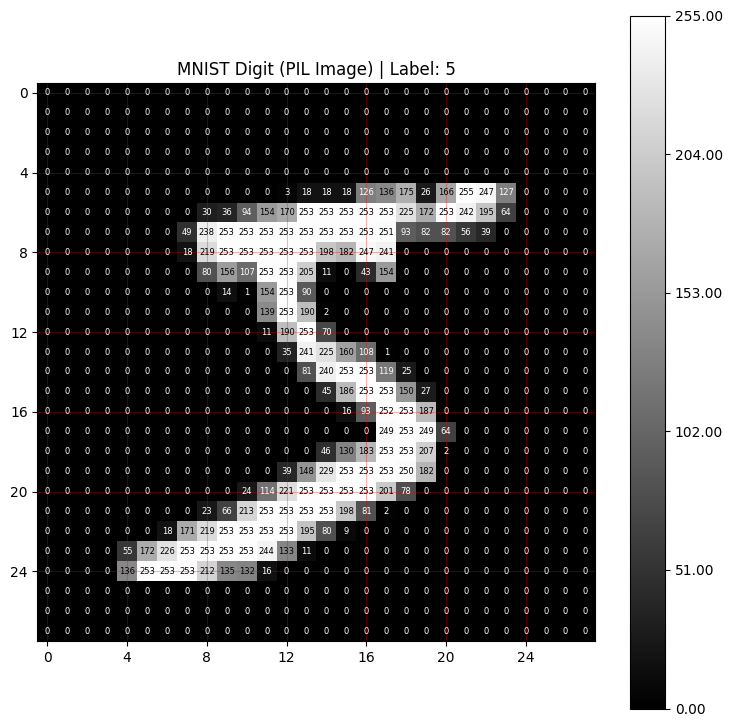

In [37]:
(helper_utils_image_classifier.display_image(image_pil, label_pil, "MNIST Digit (PIL Image)", show_values=True))

In [38]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST mean and std
])

In [39]:
train_dataset = torchvision.datasets.MNIST(
    root=data_path,     # Path to the directory where the data is/will be stored
    train=True,         # Specify that you want the training split of the dataset
    download=True,      # Download the data if it's not found in the root directory
    transform=transform # Apply the defined transformations to each image
)

In [40]:
image_tensor, label = train_dataset[0]

print(f"Image Type:                   {type(image_tensor)}")
# Since the `image` is now a PyTorch Tensor, its dimensions are accessed using the .shape attribute.
print(f"Image Shape After Transform:  {image_tensor.shape}")
print(f"Label Type:                   {type(label)}")
print(f"Label value:                  {label}")

Image Type:                   <class 'torch.Tensor'>
Image Shape After Transform:  torch.Size([1, 28, 28])
Label Type:                   <class 'int'>
Label value:                  5


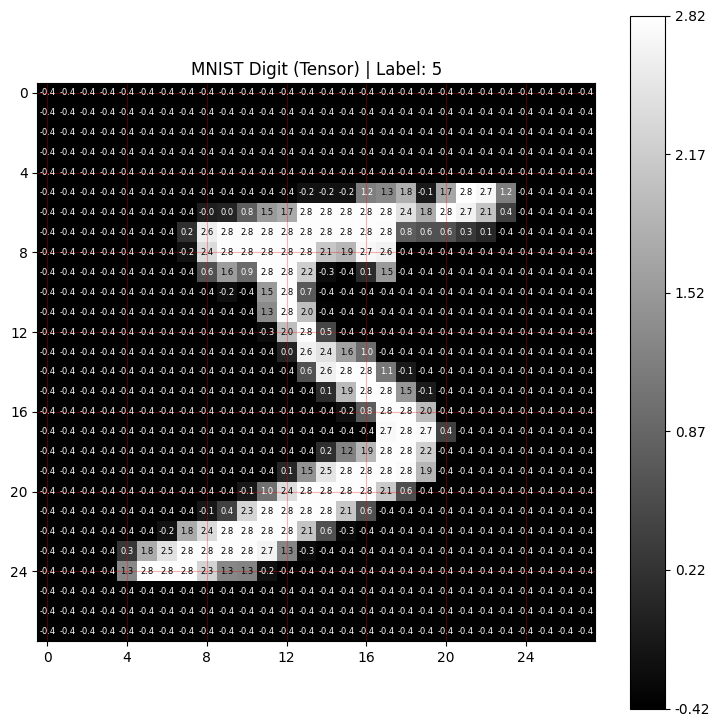

In [41]:
helper_utils_image_classifier.display_image(image_tensor, label, "MNIST Digit (Tensor)", show_values=True)

In [42]:
test_dataset = torchvision.datasets.MNIST(
    root=data_path, train=False, download=True, transform=transform
)

### Creating DataLoaders

In [43]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Building the NN Model

### Define the Model

In [44]:
class SimpleMNISTDNN(nn.Module):
    """
    A simple deep neural network model for the MNIST dataset.

    This model consists of a flatten layer followed by two linear layers
    with a ReLU activation function. It is designed for classification tasks
    on 28x28 grayscale images.
    """
    def __init__(self):
        """
        Initializes the layers of the neural network.
        """
        super(SimpleMNISTDNN, self).__init__()
        # Initializes a layer to flatten the input tensor.
        # 28x28 input image to a 784-dimensional vector.
        self.flatten = nn.Flatten()
        # Initializes the sequential layers of the neural network
        self.layers = nn.Sequential(
            # Defines the first linear layer with 784 input features and 128 output features.
            nn.Linear(784, 128),
            # Applies the rectified linear unit activation function.
            nn.ReLU(),
            # Defines the second linear layer with 128 input features and 10 output features.
            nn.Linear(128, 10)
        )

    def forward(self, x):
        """
        Defines the forward pass of the model.

        Args:
            x: The input tensor.

        Returns:
            The output tensor after passing through the network layers.
        """
        # Flattens the input tensor.
        x = self.flatten(x)
        # Passes the flattened tensor through the sequential layers.
        x = self.layers(x)
        return x

## Training the Model

### Initialize Model, Loss Function, and Optimizer

In [45]:
model = SimpleMNISTDNN()

loss_function = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

### Define the Training Function

In [46]:
def train_epoch(model, loss_function, optimizer, train_loader, device):
    """
    Trains a PyTorch model for a single epoch.

    This function iterates over the training dataset, performs the forward and
    backward passes, and updates the model's weights. It also tracks and
    prints the loss and accuracy at specified intervals.

    Args:
        model: The neural network model to be trained.
        loss_function: The loss function used to calculate the error.
        optimizer: The optimizer used to update the model's weights.
        train_loader: The DataLoader providing batches of training data.
        device: The device (e.g., 'cuda' or 'cpu') on which to perform training.

    Returns:
        A tuple containing:
        - model: The model after training for one epoch.
        - avg_epoch_loss: The average loss calculated over all batches in the epoch.
    """
    # Ensure the model is on the correct device for training
    model = model.to(device)
    # Set the model to training mode
    model.train()

    # Initialize trackers for the entire epoch's loss
    epoch_loss = 0.0

    # Initialize trackers for periodic progress reporting
    running_loss = 0.0
    num_correct_predictions = 0
    total_predictions = 0
    total_batches = len(train_loader)

    # Iterate over the training data in batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move the current batch of data to the specified device
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear any gradients from the previous iteration
        optimizer.zero_grad()

        # Perform a forward pass to get model predictions
        outputs = model(inputs)

        # Calculate the loss for the current batch
        loss = loss_function(outputs, targets)

        # Perform backpropagation to compute gradients
        loss.backward()

        # Update the model's weights based on the computed gradients
        optimizer.step()

        # Accumulate the loss for tracking and reporting
        loss_value = loss.item()
        epoch_loss += loss_value
        running_loss += loss_value

        # Calculate accuracy metrics for the current batch
        _, predicted_indices = outputs.max(1)
        batch_size = targets.size(0)
        total_predictions += batch_size
        num_correct_in_batch = predicted_indices.eq(targets).sum().item()
        num_correct_predictions += num_correct_in_batch

        # Check if it's time to print a progress update
        if (batch_idx + 1) % 134 == 0 or (batch_idx + 1) == total_batches:
            # Calculate average loss and accuracy for the current interval
            avg_running_loss = running_loss / 134
            accuracy = 100. * num_correct_predictions / total_predictions

            # Print the progress update
            print(f'\tStep {batch_idx + 1}/{total_batches} - Loss: {avg_running_loss:.3f} | Acc: {accuracy:.2f}%')

            # Reset the trackers for the next reporting interval
            running_loss = 0.0
            num_correct_predictions = 0
            total_predictions = 0

    # Calculate the average loss for the entire epoch
    avg_epoch_loss = epoch_loss / total_batches
    # Return the trained model and the average epoch loss
    return model, avg_epoch_loss

### Define the Evaluation Function

In [47]:
def evaluate(model, test_loader, device):
    """
    Evaluates the model's accuracy on a test dataset.

    This function sets the model to evaluation mode, iterates through the test data,
    and calculates the percentage of correct predictions.

    Args:
        model: The neural network model to be evaluated.
        test_loader: A data loader containing the test dataset.
        device: The device (e.g., 'cpu' or 'cuda') to run the evaluation on.

    Returns:
        The accuracy of the model on the test dataset as a percentage.
    """
    # Sets the model to evaluation mode.
    model.eval()
    # Initializes a counter for correct predictions.
    num_correct_predictions = 0
    # Initializes a counter for the total number of predictions.
    total_predictions = 0

    # Disables gradient calculation to reduce memory usage and speed up computations.
    with torch.no_grad():
        # Iterates over all batches in the test data loader.
        for inputs, targets in test_loader:
            # Moves the input data and targets to the specified device.
            inputs, targets = inputs.to(device), targets.to(device)

            # Performs a forward pass to get the model's output.
            outputs = model(inputs)

            # Retrieves the index of the highest value in the output tensor, which represents the predicted class.
            _, predicted_indices = outputs.max(1)

            # Gets the size of the current batch.
            batch_size = targets.size(0)
            # Adds the batch size to the total number of predictions.
            total_predictions = total_predictions + batch_size

            # Compares the predicted indices with the actual target values.
            correct_predictions = predicted_indices.eq(targets)
            # Sums the correct predictions in the current batch.
            num_correct_in_batch = correct_predictions.sum().item()
            # Adds the correct predictions from the current batch to the total count.
            num_correct_predictions = num_correct_predictions + num_correct_in_batch

    # Calculates the overall accuracy as a percentage.
    accuracy_percentage = (num_correct_predictions / total_predictions) * 100
    # Prints the calculated accuracy to the console.
    print((f'\tAccuracy - {accuracy_percentage:.2f}%'))

    return accuracy_percentage

### The Training Loop

In [48]:
# Set the total number of training epochs (Feel free to set a different number)
num_epochs = 5

# Initialize lists to store metrics from each epoch for later analysis
train_loss = []
test_acc = []

# Begin the training and evaluation process
for epoch in range(num_epochs):
    print(f'\n[Training] Epoch {epoch+1}:')
    # Call the training function to train the model for one epoch
    trained_model, loss = train_epoch(model, loss_function, optimizer, train_loader, device)
    # Store the average training loss for the epoch
    train_loss.append(loss)

    print(f'[Testing] Epoch {epoch+1}:')
    # Call the evaluation function to measure performance on the test set
    accuracy = evaluate(trained_model, test_loader, device)
    # Store the test accuracy for the epoch
    test_acc.append(accuracy)


[Training] Epoch 1:
	Step 134/938 - Loss: 0.572 | Acc: 83.17%
	Step 268/938 - Loss: 0.300 | Acc: 91.22%
	Step 402/938 - Loss: 0.244 | Acc: 92.82%
	Step 536/938 - Loss: 0.197 | Acc: 94.05%
	Step 670/938 - Loss: 0.186 | Acc: 94.39%
	Step 804/938 - Loss: 0.166 | Acc: 95.06%
	Step 938/938 - Loss: 0.152 | Acc: 95.53%
[Testing] Epoch 1:
	Accuracy - 95.71%

[Training] Epoch 2:
	Step 134/938 - Loss: 0.136 | Acc: 95.83%
	Step 268/938 - Loss: 0.122 | Acc: 96.35%
	Step 402/938 - Loss: 0.113 | Acc: 96.39%
	Step 536/938 - Loss: 0.124 | Acc: 96.30%
	Step 670/938 - Loss: 0.110 | Acc: 96.58%
	Step 804/938 - Loss: 0.096 | Acc: 96.89%
	Step 938/938 - Loss: 0.099 | Acc: 97.17%
[Testing] Epoch 2:
	Accuracy - 96.88%

[Training] Epoch 3:
	Step 134/938 - Loss: 0.082 | Acc: 97.61%
	Step 268/938 - Loss: 0.069 | Acc: 97.74%
	Step 402/938 - Loss: 0.078 | Acc: 97.50%
	Step 536/938 - Loss: 0.087 | Acc: 97.31%
	Step 670/938 - Loss: 0.080 | Acc: 97.31%
	Step 804/938 - Loss: 0.080 | Acc: 97.55%
	Step 938/938 - Loss:

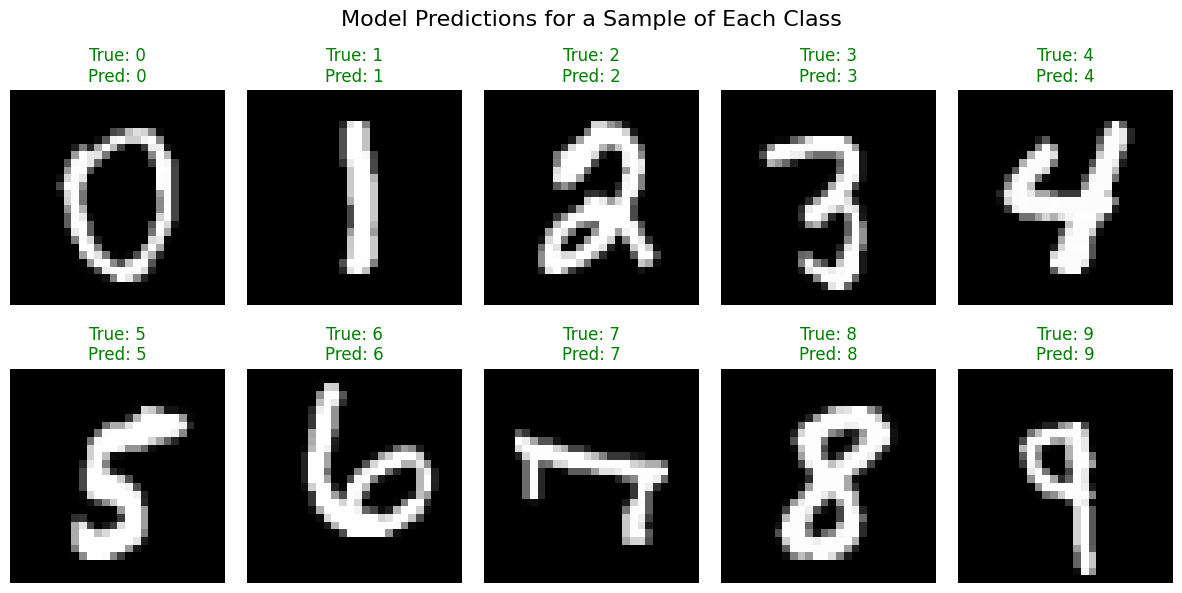

In [50]:
# Visualize model predictions on a random sample of test images
helper_utils_image_classifier.display_predictions(trained_model, test_loader, device)

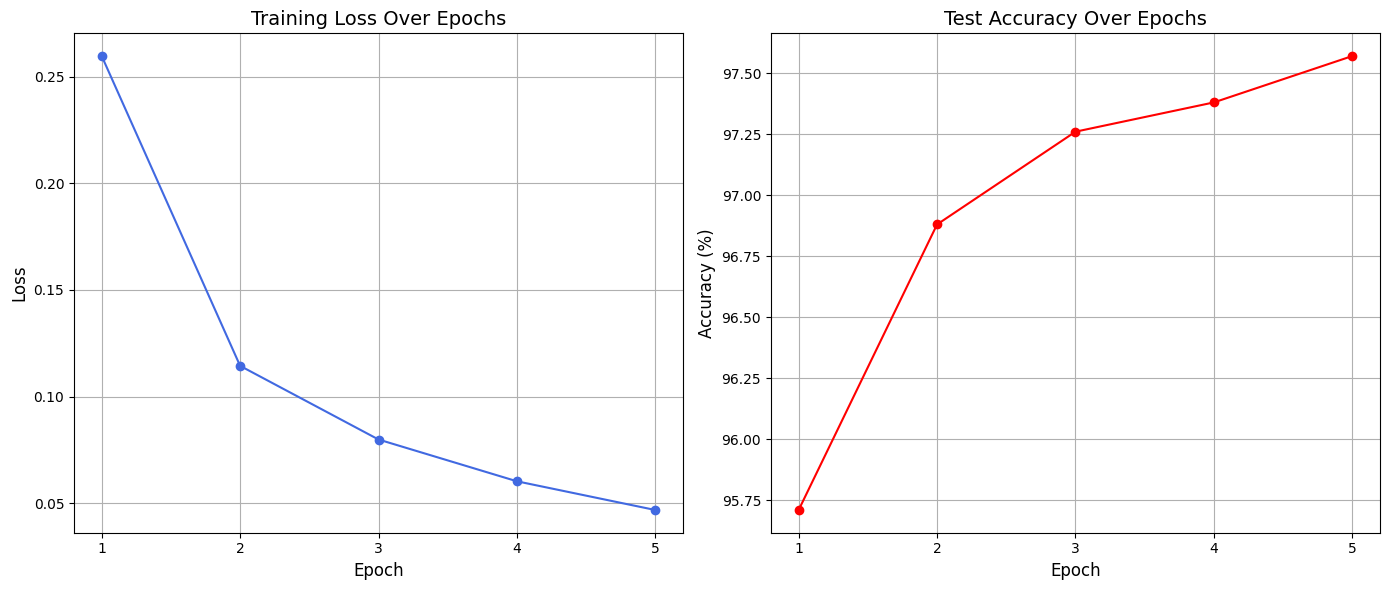

In [52]:
# Plot the training loss and test accuracy curves over all epochs
helper_utils_image_classifier.plot_metrics(train_loss, test_acc)